# Лабораторная работа №5: Кластеризация данных

## Цель работы
Изучение методов кластеризации данных: минимаксного алгоритма и алгоритма K-внутригрупповых средних.

## Постановка задачи

**Исходные данные:** Математические ожидания для пяти случайных векторов признаков.

**План выполнения работы:**
1. Смоделировать и изобразить графически обучающие выборки объема N=50 для пяти нормально распределенных двумерных случайных векторов
2. Объединить пять выборок в одну (общее количество векторов: 250)
3. Разработать программу кластеризации данных с использованием максиминного алгоритма
4. Разработать программу кластеризации данных с использованием алгоритма K-внутригрупповых средних

In [183]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Создание директории для сохранения данных
os.makedirs('lab6', exist_ok=True)

# Настройка графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

### Вспомогательные функции для генерации нормально распределенных данных

Функции для генерации случайных векторов с заданным математическим ожиданием и корреляционной матрицей.

In [ ]:
def normal_number() -> float:
    S = np.random.uniform(0., 1., 80).sum()
    number = (S - (0.5 * 80)) / np.sqrt(80 / 12)
    return number


def generate_normal_arr(size: tuple) -> np.ndarray:
    result = [normal_number() for i in range(size[0])]
    arr = np.array(result).reshape(size)
    return arr


def generate_normal(M: np.ndarray, B: np.ndarray, show_print: bool = False) -> np.ndarray:
    A = np.zeros((2, 2))
    A[0, 0] = np.sqrt(B[0, 0])
    A[1, 0] = B[0, 1] / A[0, 0]
    A[1, 1] = np.sqrt(B[1, 1] - np.power(A[1, 0], 2))

    k = 30  
    
    def approx_norm():
        U = np.random.uniform(0, 1, k)
        
        return (np.sum(U) - k/2) / np.sqrt(k/12)

    E = np.array([[approx_norm()], [approx_norm()]])
    
    X = np.dot(A, E) + M

    if show_print:
        print("M: \n", M)
        print("B: \n", B)
        print("A: \n", A)
        print("E (N(0,1)): \n", E)
        print("X (N(M,B)): \n", X)

    return X


def generate_sample(M: np.ndarray, B: np.ndarray, N: int = 50) -> np.ndarray:
    sample = np.ndarray(shape=(M.shape[0], 0))
    for i in range(N):
        sample = np.concatenate((sample, generate_normal(M, B)), axis=1)
    return sample

def printallM(a, text="Изначальные МО"):
    print(f"{text}: ")
    for i in range(len(a)):
        print(f"Кластер[{i+1}] :\t{a[i][0]} {a[i][1]}")

In [ ]:
def calculate_d_typical(centers):
    """
    Вычисляет типичное расстояние как половину среднего расстояния между центрами кластеров
    """
    d = lambda x, z: np.linalg.norm(x - z)
    d_arr = []
    for i in range(len(centers)):
        for j in range(i + 1, len(centers)):
            d_arr.append(d(centers[i], centers[j]))
    return (1 / 2) * np.mean(d_arr)


## 1. Генерация обучающих выборок

### 1.1 Задание исходных данных

Математические ожидания и корреляционные матрицы для пяти классов:

In [185]:
# Математические ожидания для пяти классов (расположены дальше друг от друга)
M1 = np.array([[0], 
               [0]])

M2 = np.array([[-1], 
               [1]])

M3 = np.array([[-1], 
               [-1]])

M4 = np.array([[1], 
               [1]])

M5 = np.array([[1], 
               [-1]])

all_M = [M1,M2,M3,M4,M5]

# Корреляционные матрицы для пяти классов (меньшие дисперсии для компактности)
B1 = np.array([[0.1, 0], 
               [0, 0.1]])

B2 = np.array([[0.08, 0.02], 
               [0.02, 0.08]])

B3 = np.array([[0.15, 0.03], 
               [0.03, 0.15]])

B4 = np.array([[0.12, 0], 
               [0, 0.12]])

B5 = np.array([[0.3, -0.02], 
               [-0.02, 0.3]])

print("Исходные данные для генерации выборок:")
print("\nКласс 1:")
print(f"Математическое ожидание M1:\n{M1.T}")
print(f"Корреляционная матрица B1:\n{B1}")

print("\nКласс 2:")
print(f"Математическое ожидание M2:\n{M2.T}")
print(f"Корреляционная матрица B2:\n{B2}")

print("\nКласс 3:")
print(f"Математическое ожидание M3:\n{M3.T}")
print(f"Корреляционная матрица B3:\n{B3}")

print("\nКласс 4:")
print(f"Математическое ожидание M4:\n{M4.T}")
print(f"Корреляционная матрица B4:\n{B4}")

print("\nКласс 5:")
print(f"Математическое ожидание M5:\n{M5.T}")
print(f"Корреляционная матрица B5:\n{B5}")

Исходные данные для генерации выборок:

Класс 1:
Математическое ожидание M1:
[[0 0]]
Корреляционная матрица B1:
[[0.1 0. ]
 [0.  0.1]]

Класс 2:
Математическое ожидание M2:
[[-1  1]]
Корреляционная матрица B2:
[[0.08 0.02]
 [0.02 0.08]]

Класс 3:
Математическое ожидание M3:
[[-1 -1]]
Корреляционная матрица B3:
[[0.15 0.03]
 [0.03 0.15]]

Класс 4:
Математическое ожидание M4:
[[1 1]]
Корреляционная матрица B4:
[[0.12 0.  ]
 [0.   0.12]]

Класс 5:
Математическое ожидание M5:
[[ 1 -1]]
Корреляционная матрица B5:
[[ 0.3  -0.02]
 [-0.02  0.3 ]]


### 1.2 Генерация и визуализация выборок

Генерация 5 выборок по 50 векторов каждая:

In [201]:
# Генерация выборок объемом N=50 для каждого класса
sample_1 = generate_sample(M1, B1)
sample_2 = generate_sample(M2, B2)
sample_3 = generate_sample(M3, B3)
sample_4 = generate_sample(M4, B4)
sample_5 = generate_sample(M5, B5)

print("Выборки успешно сгенерированы и сохранены!")
print(f"Размер каждой выборки: {sample_1.shape}")

Выборки успешно сгенерированы и сохранены!
Размер каждой выборки: (2, 50)


In [202]:
# Визуализация всех пяти выборок
def show_right_version():
    plt.figure(figsize=(12, 8))
    plt.scatter(sample_1[0], sample_1[1], marker='.', s=50, label='Класс 1', alpha=0.7)
    plt.scatter(sample_2[0], sample_2[1], marker='.', s=50, label='Класс 2', alpha=0.7)
    plt.scatter(sample_3[0], sample_3[1], marker='.', s=50, label='Класс 3', alpha=0.7)
    plt.scatter(sample_4[0], sample_4[1], marker='.', s=50, label='Класс 4', alpha=0.7)
    plt.scatter(sample_5[0], sample_5[1], marker='.', s=50, label='Класс 5', alpha=0.7)

    # Отметка центров классов
    plt.scatter([M1[0], M2[0], M3[0], M4[0], M5[0]], 
            [M1[1], M2[1], M3[1], M4[1], M5[1]], 
            marker='x', s=200, c='red', linewidths=3, label='Центры классов')

    plt.xlabel('Признак X1')
    plt.ylabel('Признак X2')
    plt.title('Обучающие выборки для пяти классов (N=50 для каждого)')
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.show()

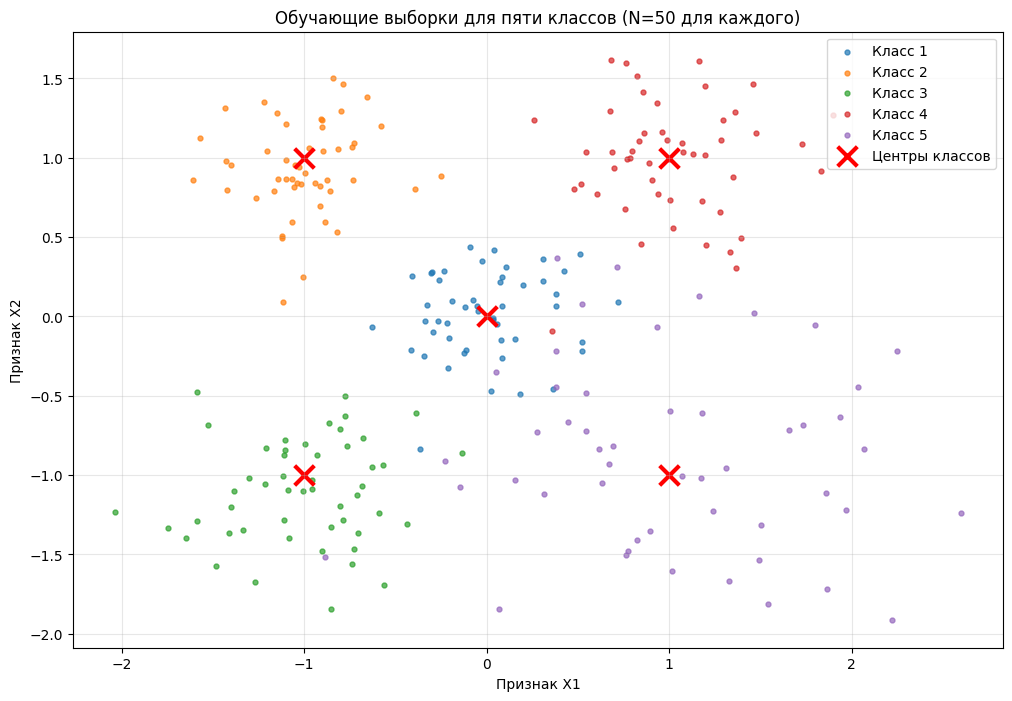

In [189]:
show_right_version()

# 2. Объединить пять выборок в одну

In [190]:

big_sample = np.concatenate((sample_1, sample_2, sample_3, sample_4, sample_5), axis=1)

print(f"Размер объединенной выборки: {big_sample.shape}")
print(f"Общее количество векторов: {big_sample.shape[1]}")

Размер объединенной выборки: (2, 250)
Общее количество векторов: 250


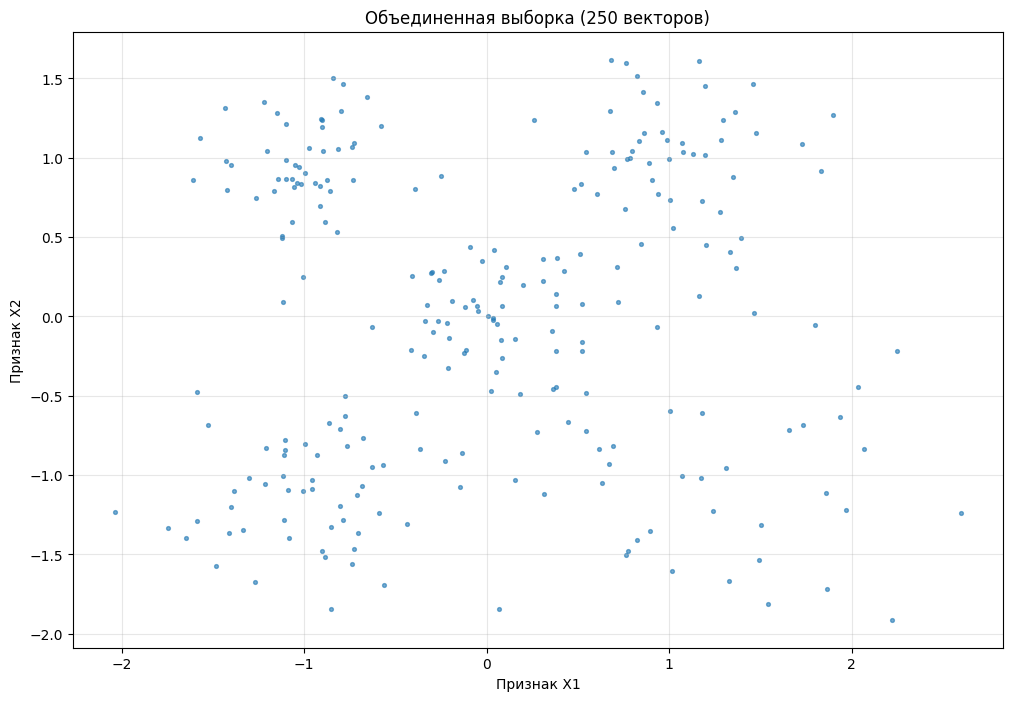

In [191]:
# Визуализация объединенной выборки
plt.figure(figsize=(12, 8))
plt.scatter(big_sample[0], big_sample[1], marker='.', s=30, alpha=0.6)
plt.xlabel('Признак X1')
plt.ylabel('Признак X2')
plt.title('Объединенная выборка (250 векторов)')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Максиминный алгоритм кластеризации

### 3.1 Реализация алгоритма

В качестве типичного расстояния берется половина среднего расстояния между существующими кластерами.

In [ ]:
def min_max_clusters(samples: np.array, count_clusters: int, show_plot=True):
    """
    Максиминный алгоритм кластеризации
    :param samples: Массив данных для кластеризации
    :param count_clusters: Желаемое количество кластеров
    :param show_plot: Показывать ли график результата
    :return: (clusters, centers, max_d_arr, typical_d_arr)
    """
    assert count_clusters >= 2
    
    d = lambda x, z: np.linalg.norm(x - z)
    samples_center = np.array([np.mean(samples[0]), np.mean(samples[1])], ndmin=2)
    samples_T = samples.T
    
    # Поиск первого центра кластера (самый удаленный от центра выборки)
    max_0 = 0
    max_0_idx = -1
    centers = []
    for i in range(len(samples_T)):
        if d(samples_T[i], samples_center) > max_0:
            max_0 = d(samples_T[i], samples_center)
            max_0_idx = i
    centers.append(samples_T[max_0_idx])

    
    # Массивы для графиков
    max_d_arr_for_graph = []
    typical_d_arr_for_graph = []

    # Выборка центров кластеров
    for k in range(count_clusters - 1):
        max_0 = 0
        max_0_idx = -1
        for i in range(len(samples_T)):
            d_min = np.finfo(np.float32).max
            for center_ind in range(len(centers)):
                if d(samples_T[i], centers[center_ind]) < d_min:
                    d_min = d(samples_T[i], centers[center_ind])
            if d_min > max_0:
                max_0 = d_min
                max_0_idx = i
        
        if k >= 2:
            if calculate_d_typical(centers) < max_0:
                centers.append(samples_T[max_0_idx])


                max_d_arr_for_graph.append(max_0)
                typical_d_arr_for_graph.append(calculate_d_typical(centers))
            else:
                print(f"Достигнуто максимальное количество кластеров: {len(centers)}")
                break
        else:
            centers.append(samples_T[max_0_idx])

            
            max_d_arr_for_graph.append(max_0)
            typical_d_arr_for_graph.append(calculate_d_typical(centers))

    # Распределение точек по кластерам
    clusters = [[] for _ in range(len(centers))]
    for i in range(len(samples_T)):
        d_min = np.finfo(np.float32).max
        cluster_ind = -1
        for j in range(len(centers)):
            if d(samples_T[i], centers[j]) < d_min:
                d_min = d(samples_T[i], centers[j])
                cluster_ind = j
        clusters[cluster_ind].append(samples_T[i])

    for i in range(len(centers)):
        clusters[i] = np.array(clusters[i]).T

    # Визуализация
    if show_plot:
        plt.figure(figsize=(12, 8))
        for i in range(len(centers)):
            plt.scatter(clusters[i][0], clusters[i][1], marker='.', s=50, 
                       label=f'Кластер {i+1}', alpha=0.6)
            plt.scatter(centers[i][0], centers[i][1], marker='x', s=300, 
                       color='red', linewidths=3)
        plt.xlabel('Признак X1')
        plt.ylabel('Признак X2')
        plt.title(f'Результат максиминной кластеризации ({len(centers)} кластеров)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.gca().set_aspect('equal') 
        plt.show()
    
    return clusters, centers, max_d_arr_for_graph, typical_d_arr_for_graph

### 3.2 Применение максиминного алгоритма

Применение алгоритма для различного числа кластеров (от 2 до 5):

Максиминная кластеризация для 2 кластеров


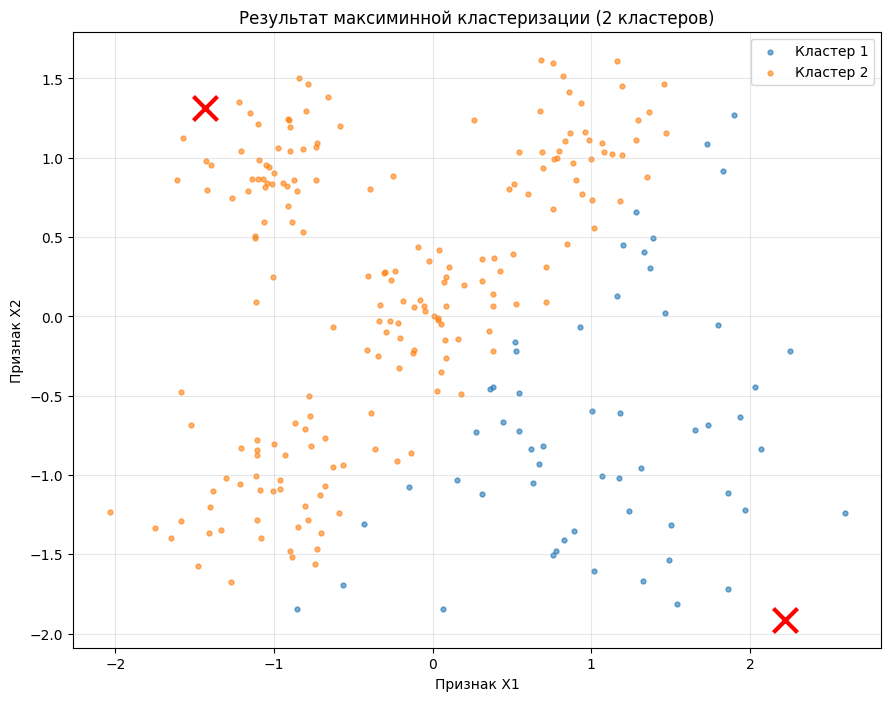

Максиминная кластеризация для 3 кластеров


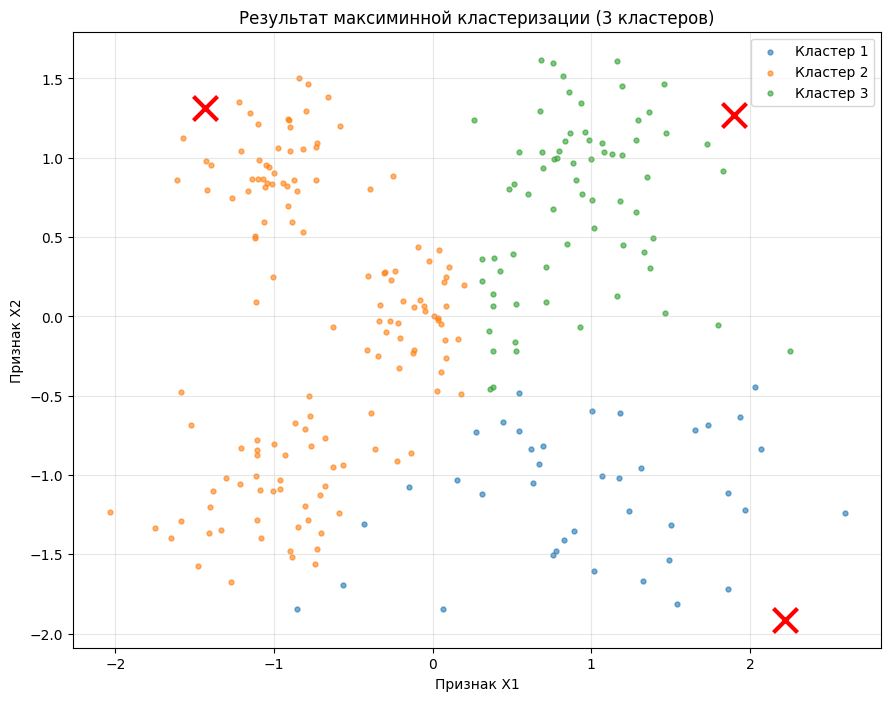

Максиминная кластеризация для 4 кластеров


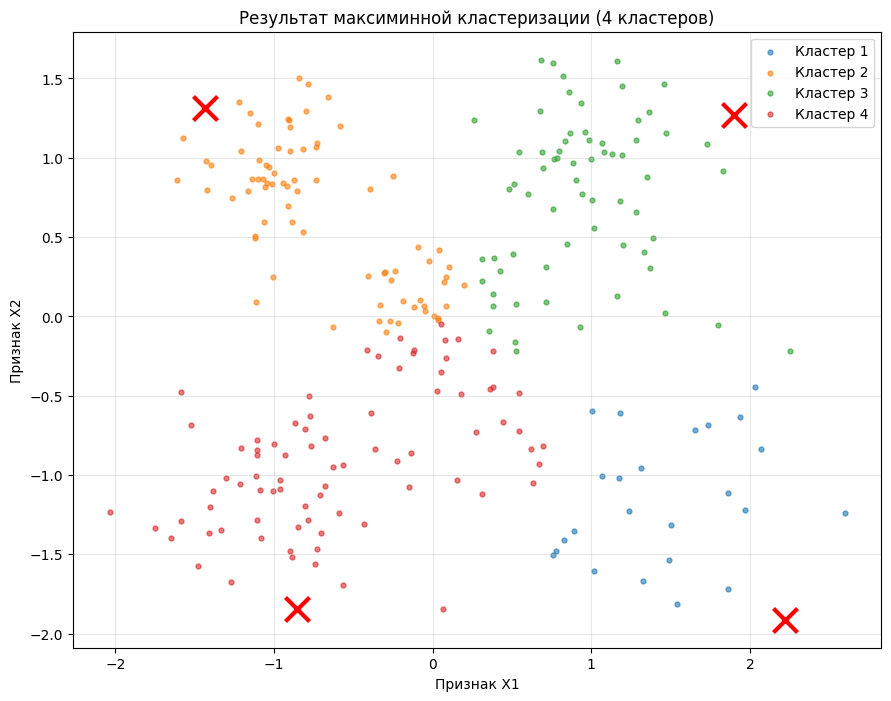

Максиминная кластеризация для 5 кластеров


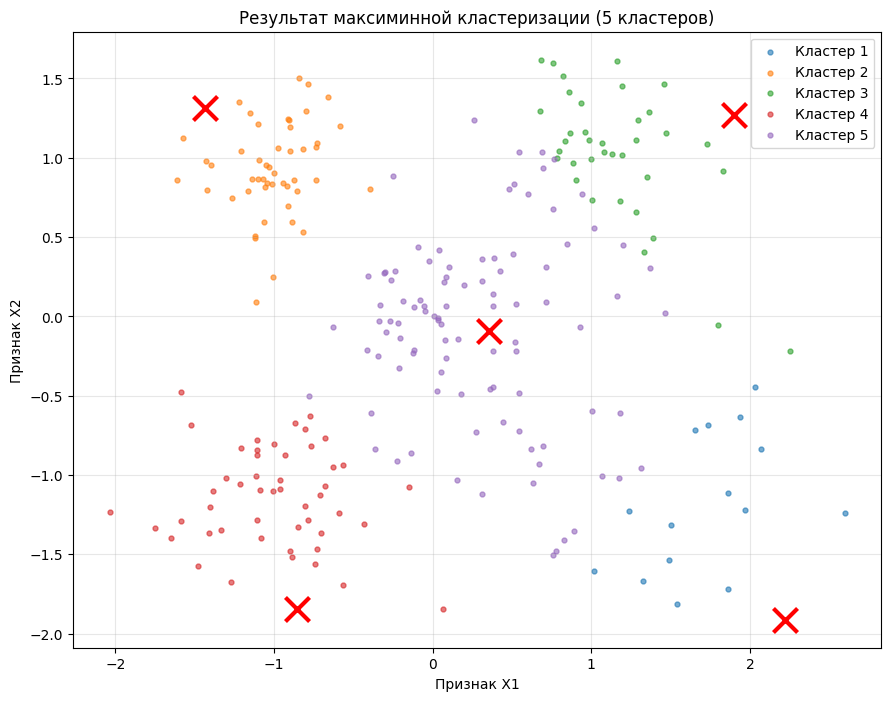

In [192]:
# Перемешивание данных для более объективной кластеризации
big_sample_shuffled = big_sample.T
np.random.shuffle(big_sample_shuffled)
big_sample_shuffled = big_sample_shuffled.T

# Применение максиминного алгоритма для разного числа кластеров
results = {}
for n_clusters in range(2, 6):
    print(f"Максиминная кластеризация для {n_clusters} кластеров")
    clusters, centers, max_d_arr, typical_d_arr = min_max_clusters(
        big_sample_shuffled, n_clusters, show_plot=True
    )
    results[n_clusters] = {
        'clusters': clusters,
        'centers': centers,
        'max_d': max_d_arr,
        'typical_d': typical_d_arr
    }

### 3.3 Графики зависимости расстояний от числа кластеров

Построение графиков зависимости максимального и типичного расстояний от числа кластеров:

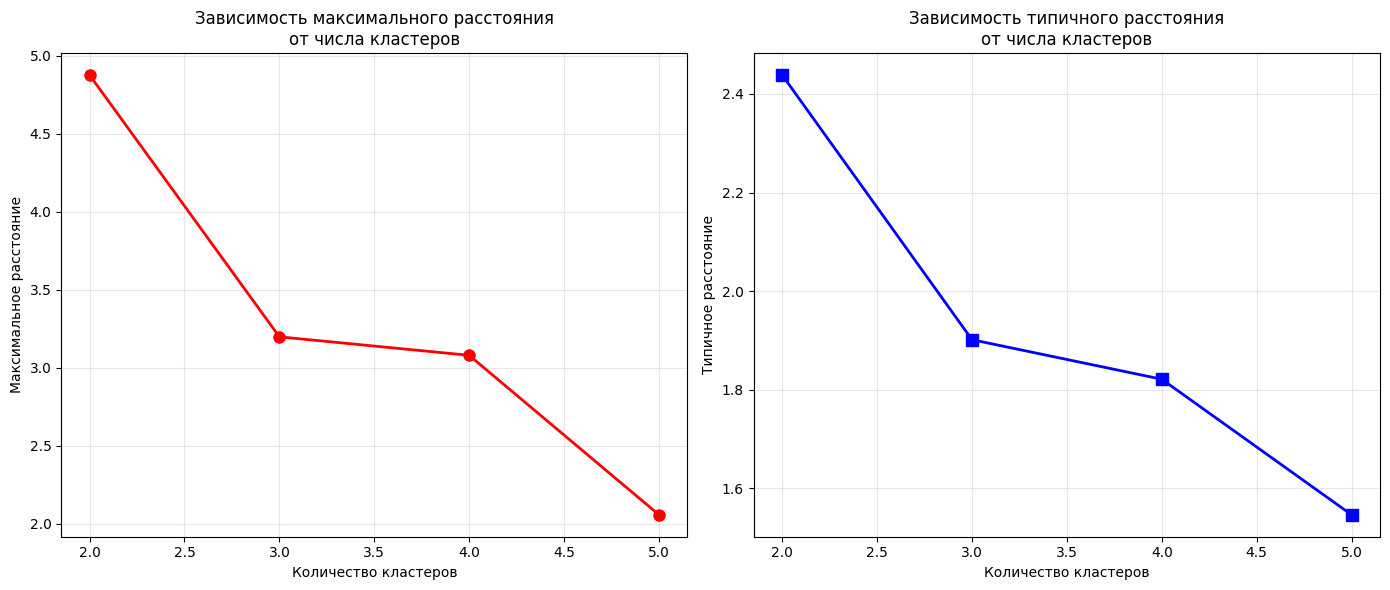


Полученное число кластеров: 5


In [193]:
# Сбор данных для графиков из результатов кластеризации с 5 кластерами
if 5 in results:
    max_d_values = results[5]['max_d']
    typical_d_values = results[5]['typical_d']
    
    x_values = np.arange(2, 2 + len(max_d_values))
    
    plt.figure(figsize=(14, 6))
    
    # График максимального расстояния
    plt.subplot(1, 2, 1)
    plt.plot(x_values, max_d_values, marker='o', linewidth=2, markersize=8, color='red')
    plt.xlabel('Количество кластеров')
    plt.ylabel('Максимальное расстояние')
    plt.title('Зависимость максимального расстояния\nот числа кластеров')
    plt.grid(True, alpha=0.3)
    
    # График типичного расстояния
    plt.subplot(1, 2, 2)
    plt.plot(x_values, typical_d_values, marker='s', linewidth=2, markersize=8, color='blue')
    plt.xlabel('Количество кластеров')
    plt.ylabel('Типичное расстояние')
    plt.title('Зависимость типичного расстояния\nот числа кластеров')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nПолученное число кластеров: {len(results[5]['centers'])}")

## 4. Алгоритм K-внутригрупповых средних (K-means)

### 4.1 Реализация алгоритма

In [ ]:
def k_mean_alg(samples: np.array, count_clusters: int, initial_centers=None, max_iterations=10, show_plots=True):
    """
    Алгоритм K-внутригрупповых средних (K-means)
    :param samples: Массив данных для кластеризации
    :param count_clusters: Количество кластеров
    :param initial_centers: Начальные центры (если None, берутся первые count_clusters точек)
    :param max_iterations: Максимальное количество итераций
    :return: (centers, count_changed_history)
    """
    samples_T = samples.T
    
    # Инициализация центров
    if initial_centers is None:
        centers = [samples_T[i].copy() for i in range(count_clusters)]
    else:
        centers = [c.copy() for c in initial_centers]
    
    new_clusters_number = []
    prev_cluster_number = []
    count_changed = []

    d = lambda x, z: np.linalg.norm(x - z)
    
    print(f"\nНачало работы алгоритма K-means для {count_clusters} кластеров")
    print(f"Начальные центры кластеров:")
    for i, c in enumerate(centers):
        print(f"  Кластер {i+1}: [{c[0]:.3f}, {c[1]:.3f}]")
    
    # Визуализация начального состояния
    if show_plots:
        plt.figure(figsize=(12, 8))
        plt.scatter(samples[0], samples[1], marker='.', s=30, alpha=0.4, color='gray', label='Все точки')
        for i, c in enumerate(centers):
            plt.scatter(c[0], c[1], marker='x', s=300, color='red', linewidths=3, label=f'Начальный центр {i+1}' if i == 0 else '')
        plt.xlabel('Признак X1')
        plt.ylabel('Признак X2')
        plt.title(f'K-means: Начальные центры ({count_clusters} кластеров)')
        plt.legend()
        plt.gca().set_aspect('equal')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    for k in range(max_iterations):
        # Распределение точек по кластерам
        clusters = [[] for _ in range(count_clusters)]
        for i in range(len(samples_T)):
            d_min = np.finfo(np.float32).max
            cluster_ind = -1
            for j in range(len(centers)):
                if d(samples_T[i], centers[j]) < d_min:
                    d_min = d(samples_T[i], centers[j])
                    cluster_ind = j
            clusters[cluster_ind].append(samples_T[i])
            new_clusters_number.append(cluster_ind)

        # Преобразование кластеров в numpy массивы
        clusters_arrays = []
        for i in range(len(clusters)):
            if len(clusters[i]) > 0:  # Если кластер не пустой
                clusters_arrays.append(np.array(clusters[i]).T)
            else:
                # Создаем пустой массив правильной формы
                clusters_arrays.append(np.array([[], []]))  # 2 строки, 0 столбцов

        # Вычисление новых центров
        centers_new = []
        for i in range(len(centers)):
            if clusters_arrays[i].shape[1] > 0:  # Если в кластере есть точки
                centers_new.append(np.array([clusters_arrays[i][0].mean(), clusters_arrays[i][1].mean()]))
            else:
                centers_new.append(centers[i])  # Оставляем старый центр

        # Проверка на сходимость
        same = True
        for i in range(len(centers)):
            if centers[i][0] != centers_new[i][0] or centers[i][1] != centers_new[i][1]:
                same = False
                break

        if not same:
            # Визуализация текущей итерации
            if show_plots:
                plt.figure(figsize=(12, 8))
                for i in range(len(centers)):
                    if clusters_arrays[i].shape[1] > 0:
                        plt.scatter(clusters_arrays[i][0], clusters_arrays[i][1], marker='.', s=50, 
                                   label=f'Кластер {i+1}', alpha=0.6)
                    plt.scatter(centers_new[i][0], centers_new[i][1], marker='x', 
                               s=300, color='red', linewidths=3)
                plt.xlabel('Признак X1')
                plt.ylabel('Признак X2')
                plt.title(f'K-means: Итерация {k+1}')
                plt.legend()
                plt.gca().set_aspect('equal') 
                plt.grid(True, alpha=0.3)
                plt.show()
            
            # Подсчет количества точек, сменивших кластер
            if k != 0:
                count = 0
                for j in range(len(new_clusters_number)):
                    if new_clusters_number[j] != prev_cluster_number[j]:
                        count += 1
                count_changed.append(count)
                print(f"Итерация {k+1}: {count} точек сменили кластер")
            
            prev_cluster_number = new_clusters_number
            new_clusters_number = []
            centers = centers_new
            continue
        else:
            print(f"\nАлгоритм сошелся на итерации {k+1}")
            return centers, count_changed
    
    print(f"\nДостигнуто максимальное количество итераций: {max_iterations}")
    return centers, count_changed

### 4.2 Применение K-means для 3 кластеров


K-MEANS: 3 КЛАСТЕРА

Начало работы алгоритма K-means для 3 кластеров
Начальные центры кластеров:
  Кластер 1: [1.831, 0.914]
  Кластер 2: [0.358, -0.092]
  Кластер 3: [-0.251, 0.882]


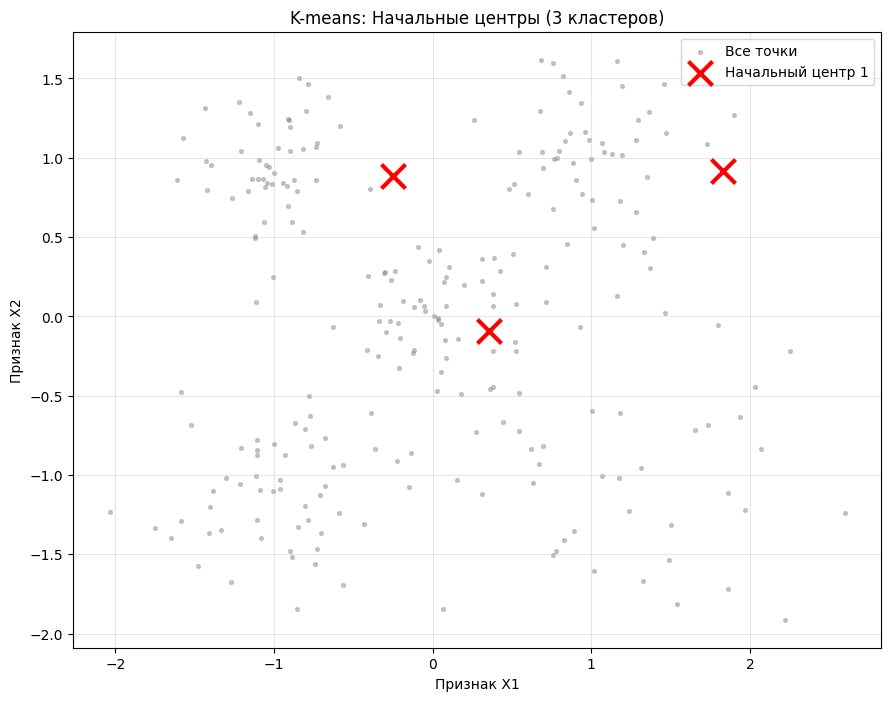

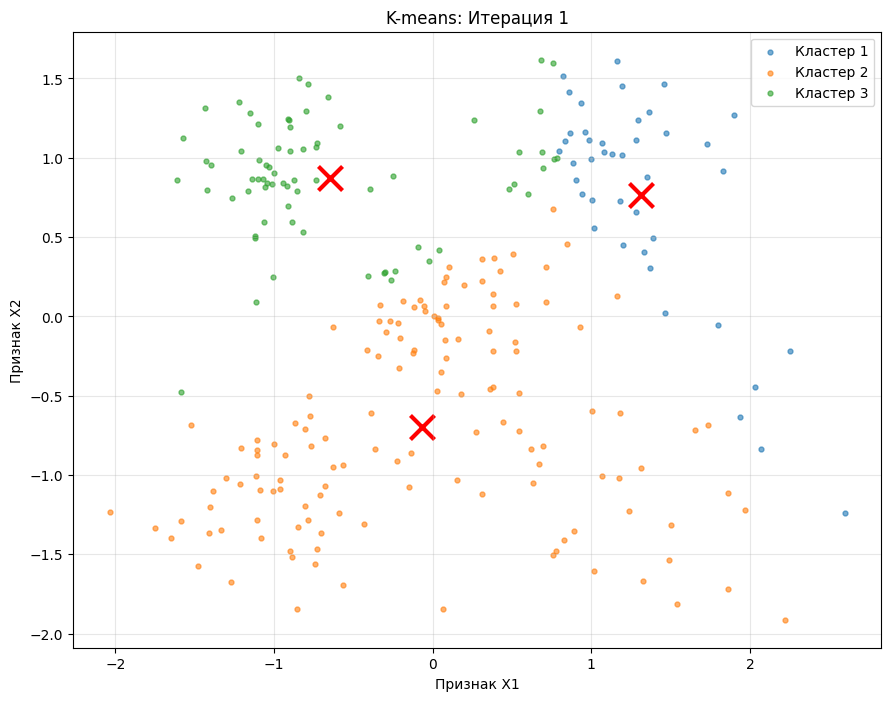

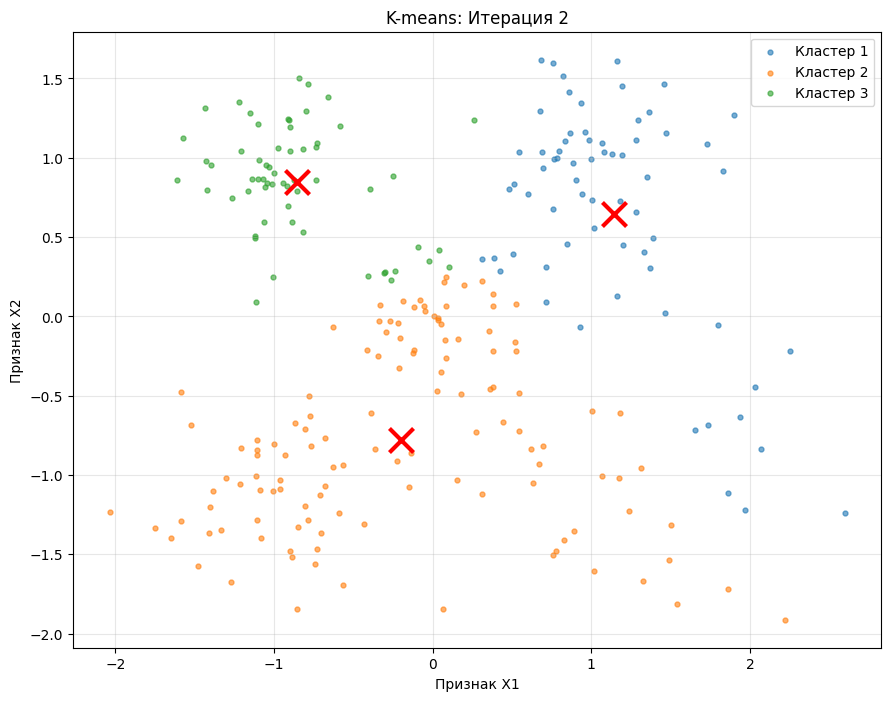

Итерация 2: 27 точек сменили кластер


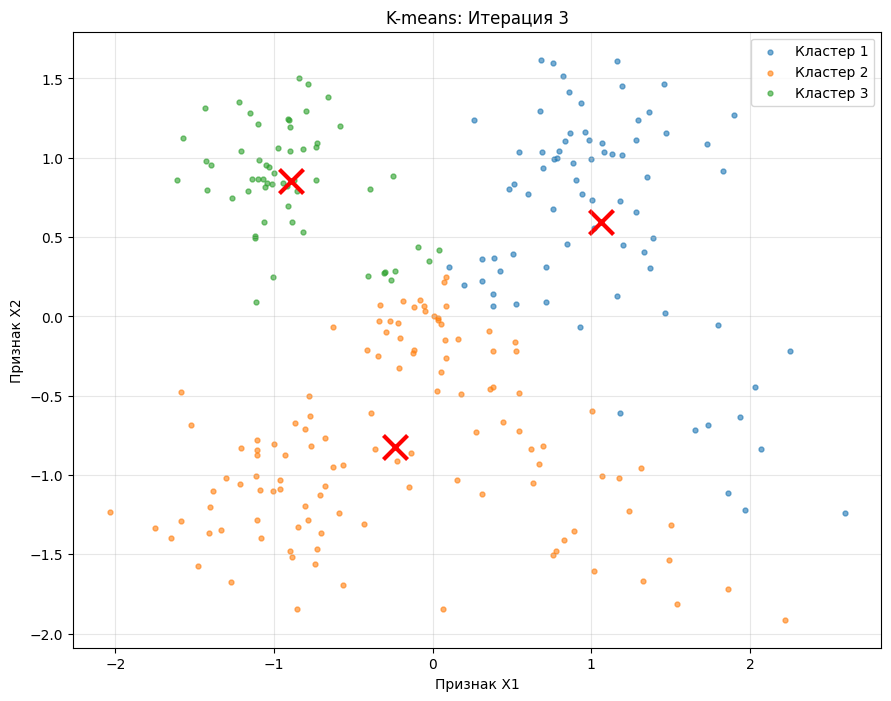

Итерация 3: 8 точек сменили кластер


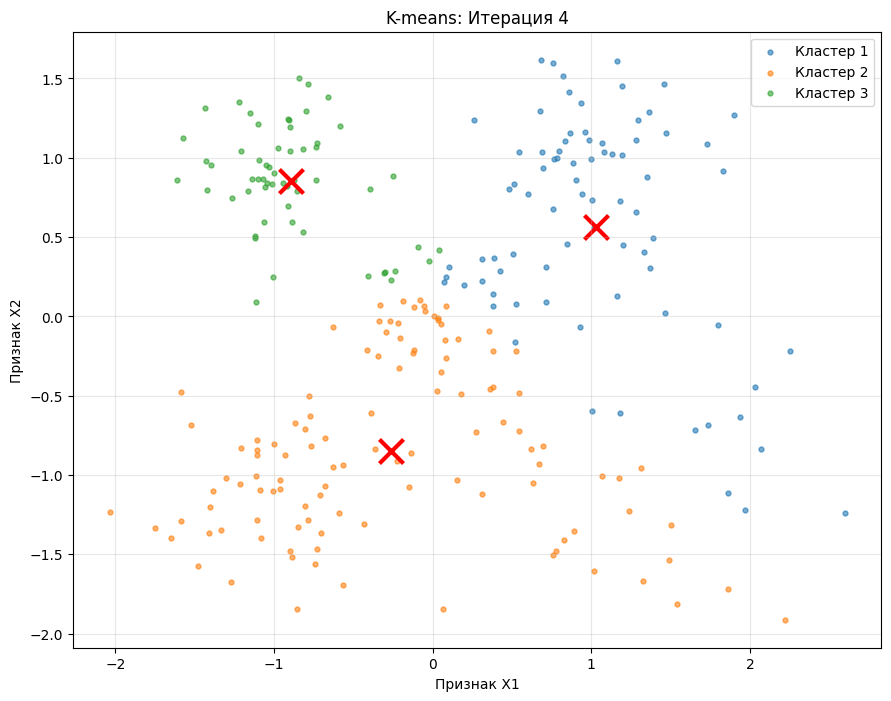

Итерация 4: 4 точек сменили кластер


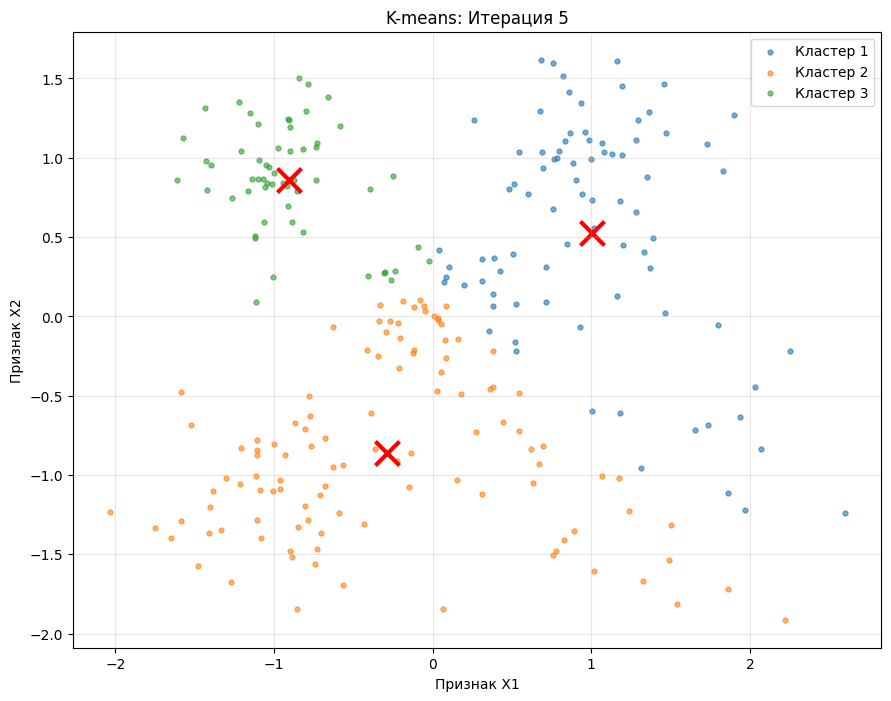

Итерация 5: 4 точек сменили кластер

Алгоритм сошелся на итерации 6


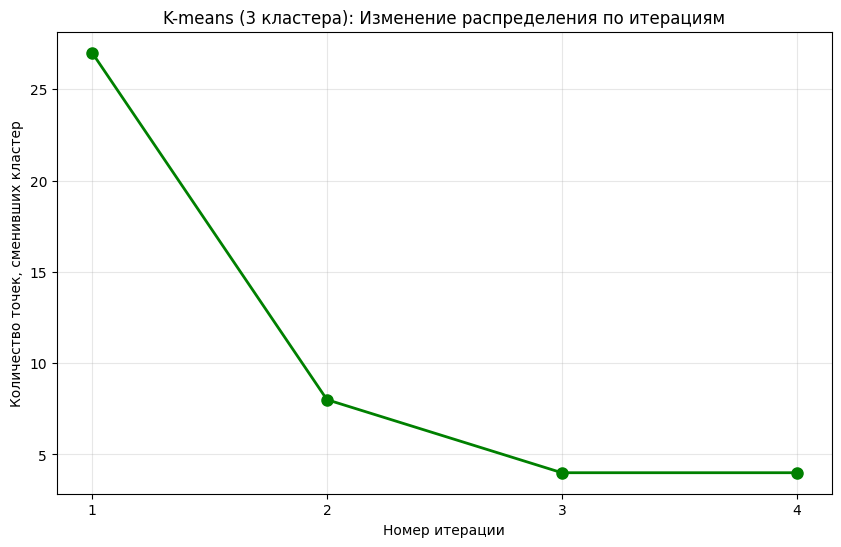

In [195]:
print("\n" + "="*70)
print("K-MEANS: 3 КЛАСТЕРА")
print("="*70)

centers_3, count_changed_3 = k_mean_alg(big_sample, 3, show_plots=True)

# График изменения количества точек, сменивших кластер
if len(count_changed_3) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(count_changed_3) + 1), count_changed_3, 
             marker='o', linewidth=2, markersize=8, color='green')
    plt.xlabel('Номер итерации')
    plt.ylabel('Количество точек, сменивших кластер')
    plt.title('K-means (3 кластера): Изменение распределения по итерациям')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, len(count_changed_3) + 1))
    plt.show()

### 4.3 Применение K-means для 5 кластеров ("правильная" кластеризация)

Начальные условия подбираются так, чтобы максимально соответствовать первоначальному разбиению на классы:


K-MEANS: 5 КЛАСТЕРОВ (ПРАВИЛЬНАЯ КЛАСТЕРИЗАЦИЯ)
Начальные центры: 
Кластер[1] :	[0] [0]
Кластер[2] :	[-1] [1]
Кластер[3] :	[-1] [-1]
Кластер[4] :	[1] [1]
Кластер[5] :	[1] [-1]
Начальные центры выбраны близко к истинным центрам классов

Начало работы алгоритма K-means для 5 кластеров
Начальные центры кластеров:
  Кластер 1: [0.000, 1.000]
  Кластер 2: [-1.500, 1.000]
  Кластер 3: [-1.500, -1.000]
  Кластер 4: [1.000, 1.500]
  Кластер 5: [0.500, 0.000]


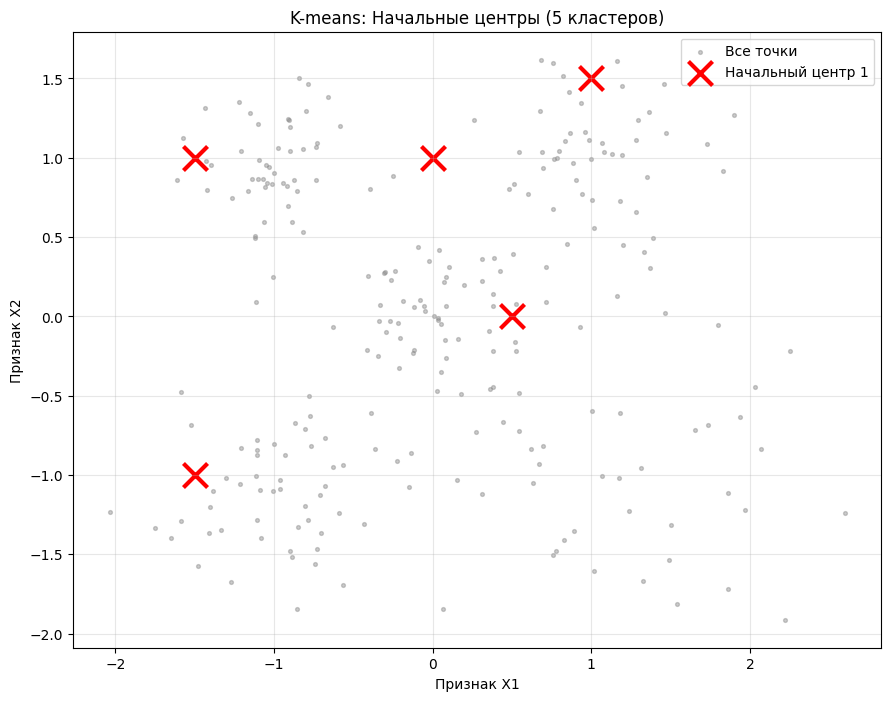

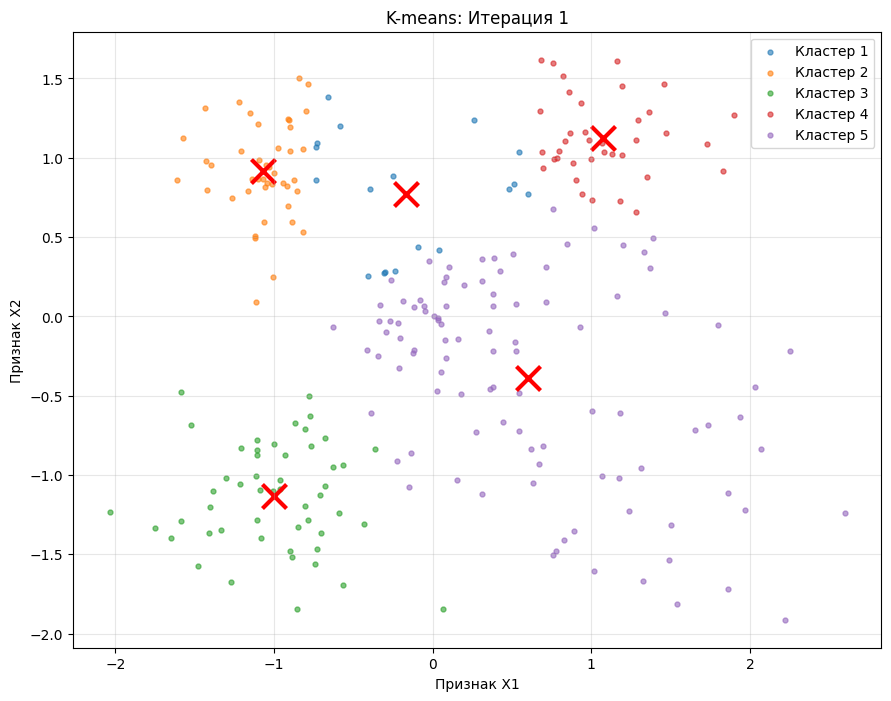

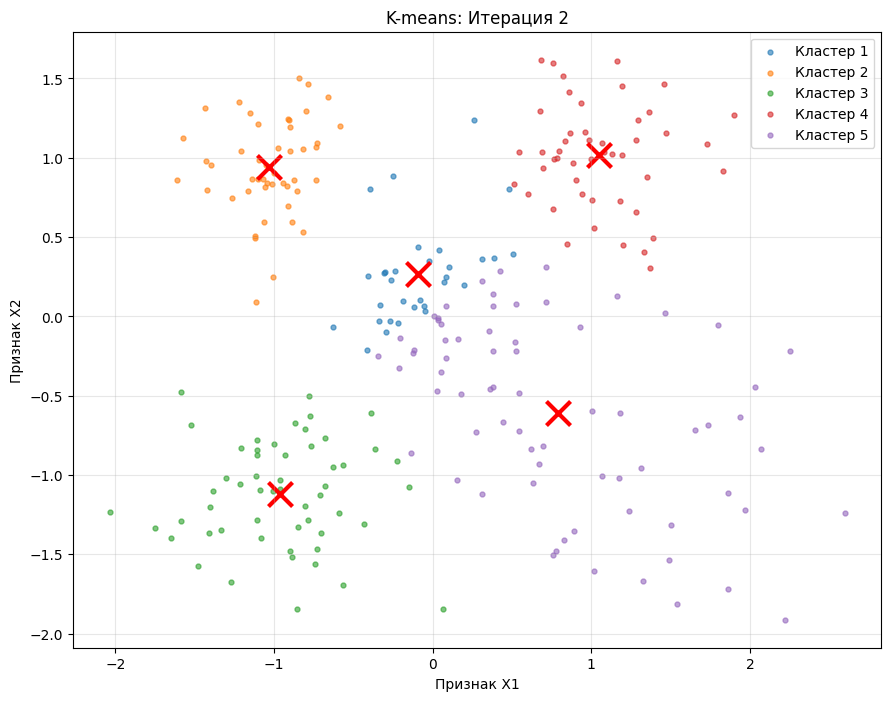

Итерация 2: 39 точек сменили кластер


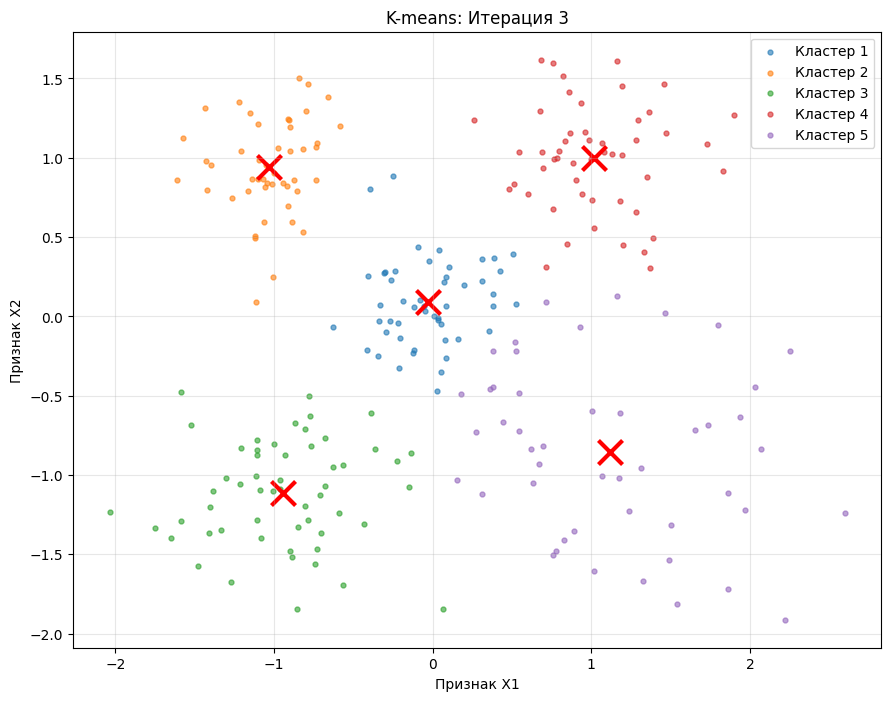

Итерация 3: 25 точек сменили кластер


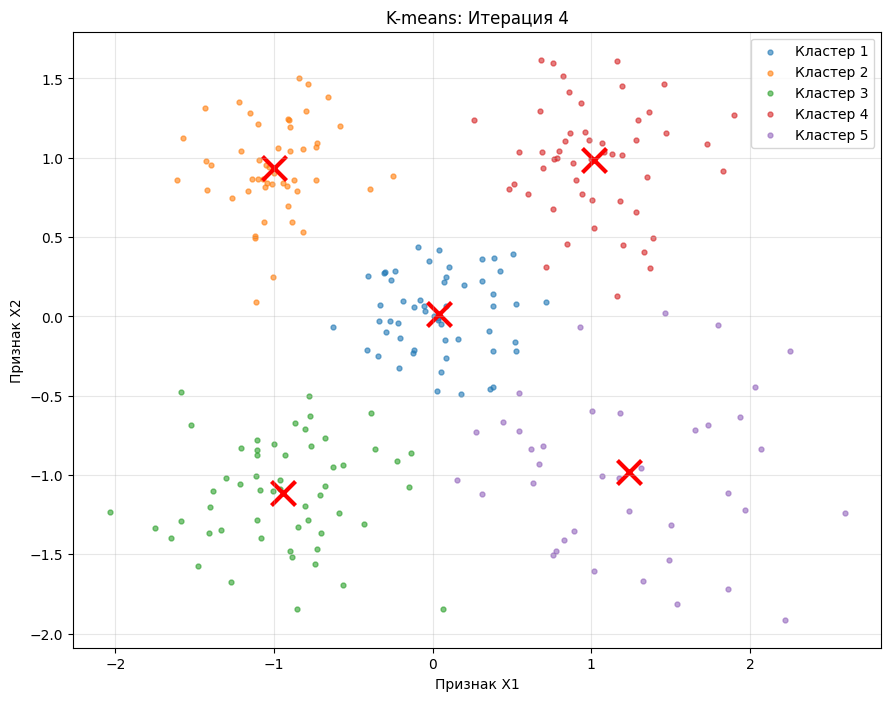

Итерация 4: 10 точек сменили кластер


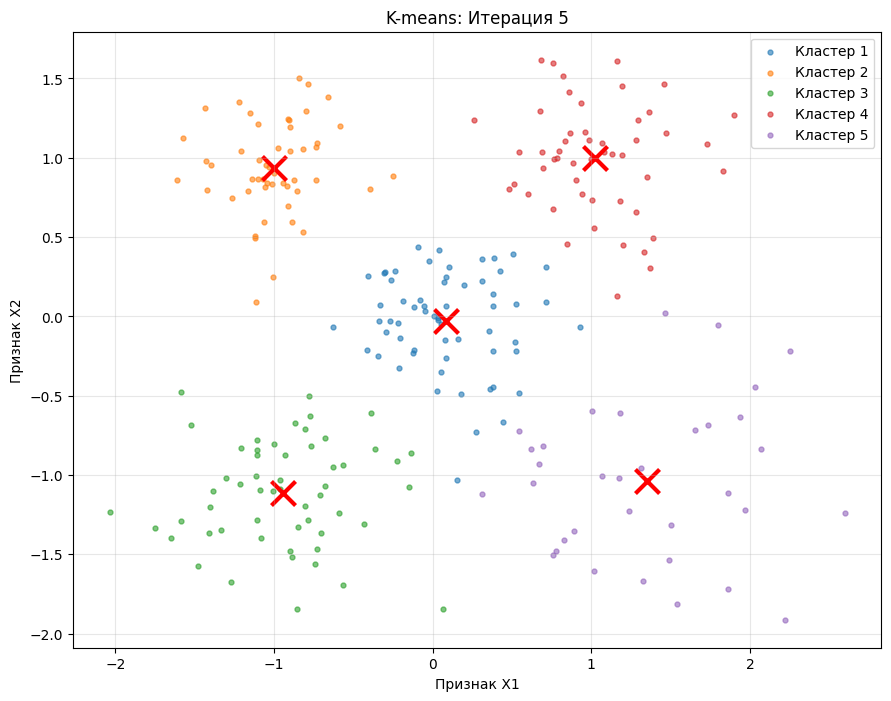

Итерация 5: 6 точек сменили кластер


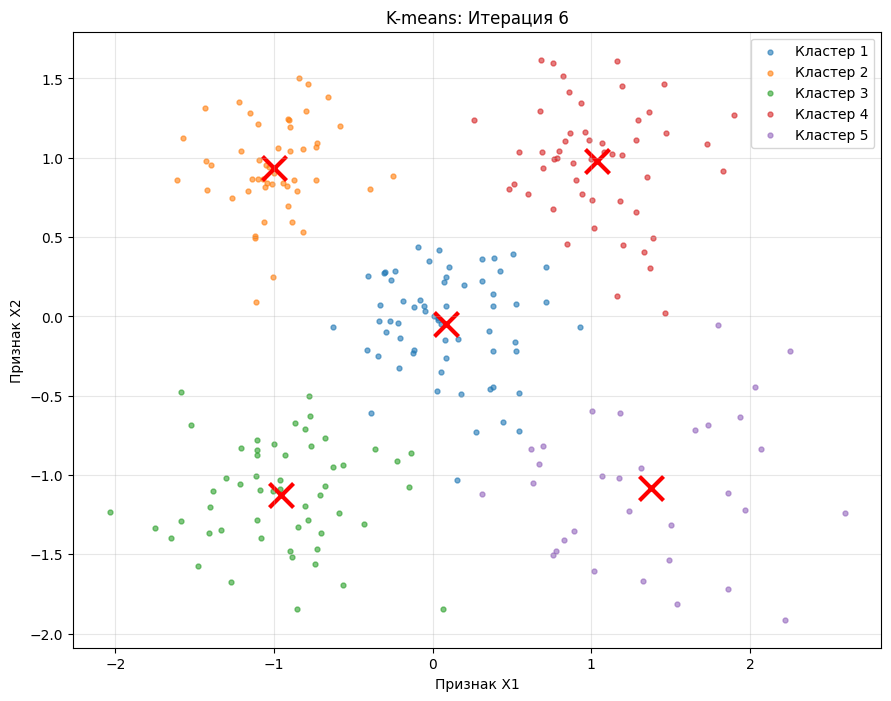

Итерация 6: 3 точек сменили кластер


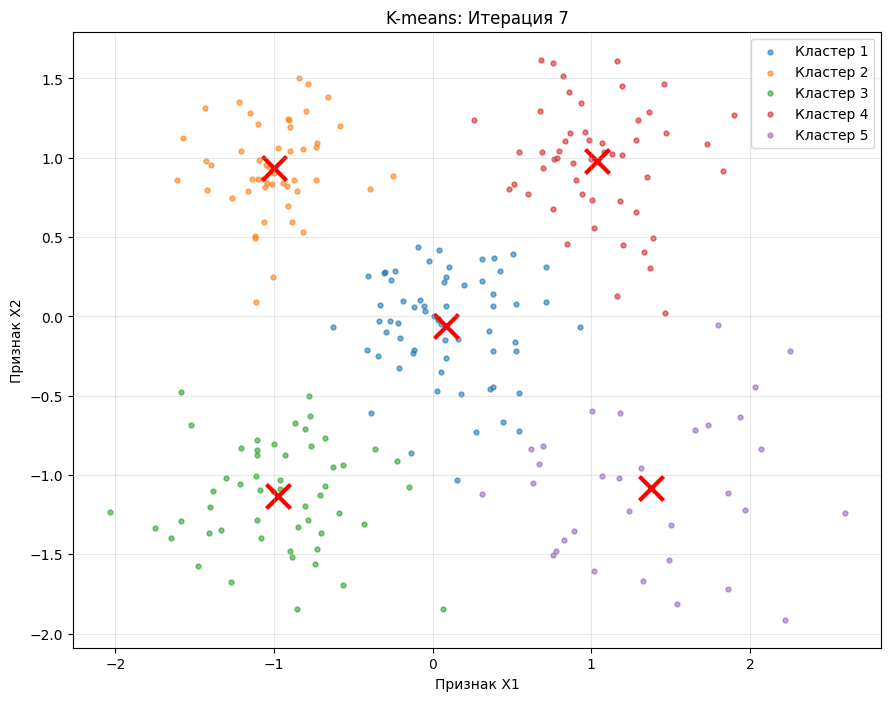

Итерация 7: 1 точек сменили кластер

Алгоритм сошелся на итерации 8


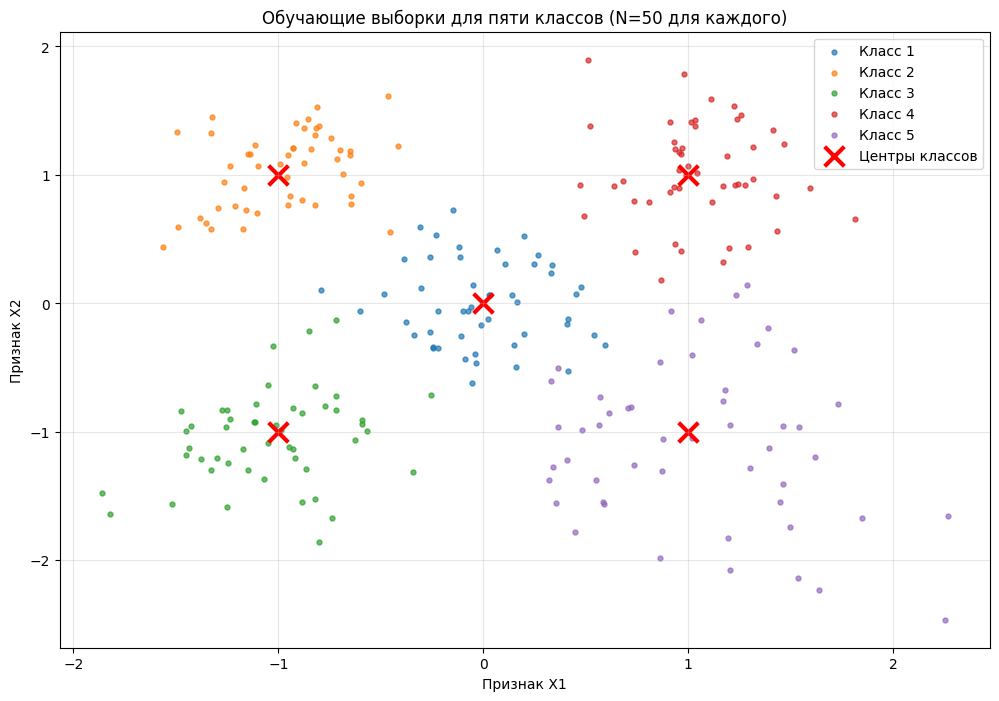

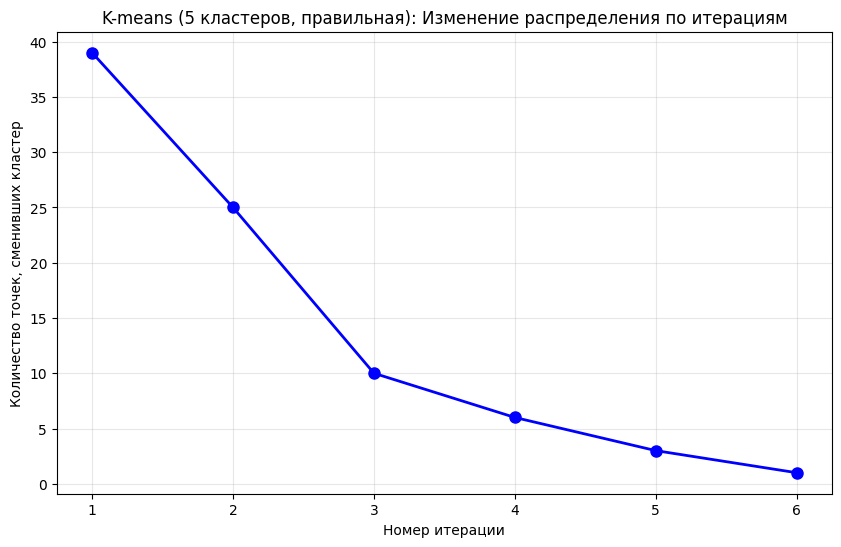

In [205]:
print("\n" + "="*70)
print("K-MEANS: 5 КЛАСТЕРОВ (ПРАВИЛЬНАЯ КЛАСТЕРИЗАЦИЯ)")
print("="*70)

printallM(all_M,"Начальные центры")
print("Начальные центры выбраны близко к истинным центрам классов")

# Начальные центры близки к истинным математическим ожиданиям
initial_centers_good = [
    np.array([0, 1.0]),    # Близко к M1
    np.array([-1.5, 1]),   # Близко к M2
    np.array([-1.5, -1]),   # Близко к M3
    np.array([1, 1.5]),   # Близко к M4
    np.array([0.5, 0])   # Близко к M5
]

centers_5_good, count_changed_5_good = k_mean_alg(
    big_sample, 5, initial_centers=initial_centers_good, show_plots=True
)
show_right_version()
# График изменения количества точек, сменивших кластер
if len(count_changed_5_good) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(count_changed_5_good) + 1), count_changed_5_good, 
             marker='o', linewidth=2, markersize=8, color='blue')
    plt.xlabel('Номер итерации')
    plt.ylabel('Количество точек, сменивших кластер')
    plt.title('K-means (5 кластеров, правильная): Изменение распределения по итерациям')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, len(count_changed_5_good) + 1))
    plt.show()


### 4.4 Применение K-means для 5 кластеров ("неправильная" кластеризация)

Начальные условия подбираются так, чтобы максимально НЕ соответствовать первоначальному разбиению на классы:


K-MEANS: 5 КЛАСТЕРОВ (НЕПРАВИЛЬНАЯ КЛАСТЕРИЗАЦИЯ)
Правильные МО: 
Кластер[1] :	[0] [0]
Кластер[2] :	[-1] [1]
Кластер[3] :	[-1] [-1]
Кластер[4] :	[1] [1]
Кластер[5] :	[1] [-1]
Начальные центры выбраны далеко от истинных центров классов

Начало работы алгоритма K-means для 5 кластеров
Начальные центры кластеров:
  Кластер 1: [-1.000, 0.000]
  Кластер 2: [-0.500, 0.500]
  Кластер 3: [0.000, 0.000]
  Кластер 4: [1.000, -1.000]
  Кластер 5: [0.000, -1.000]


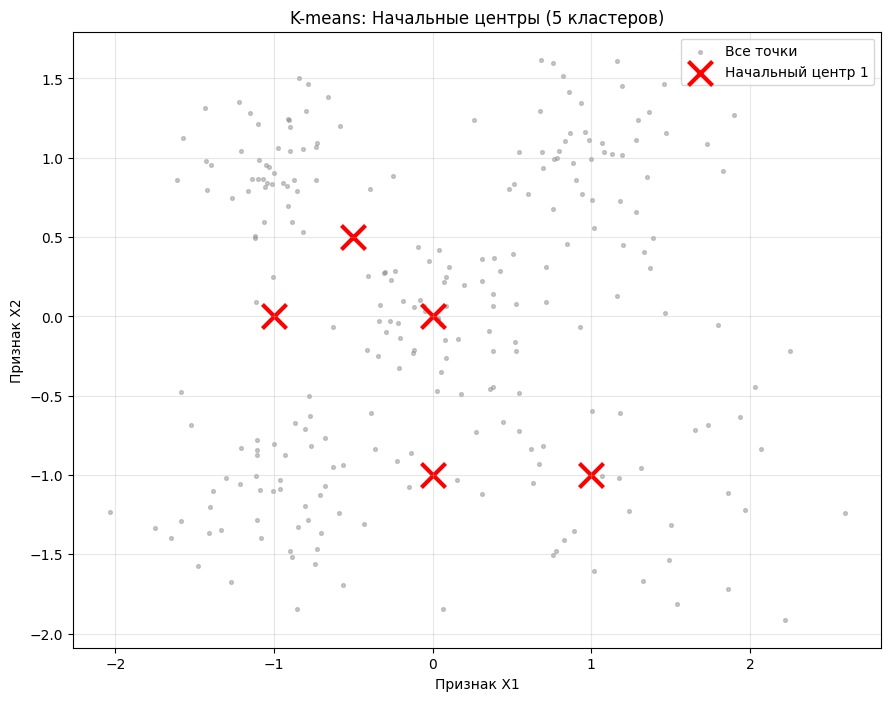

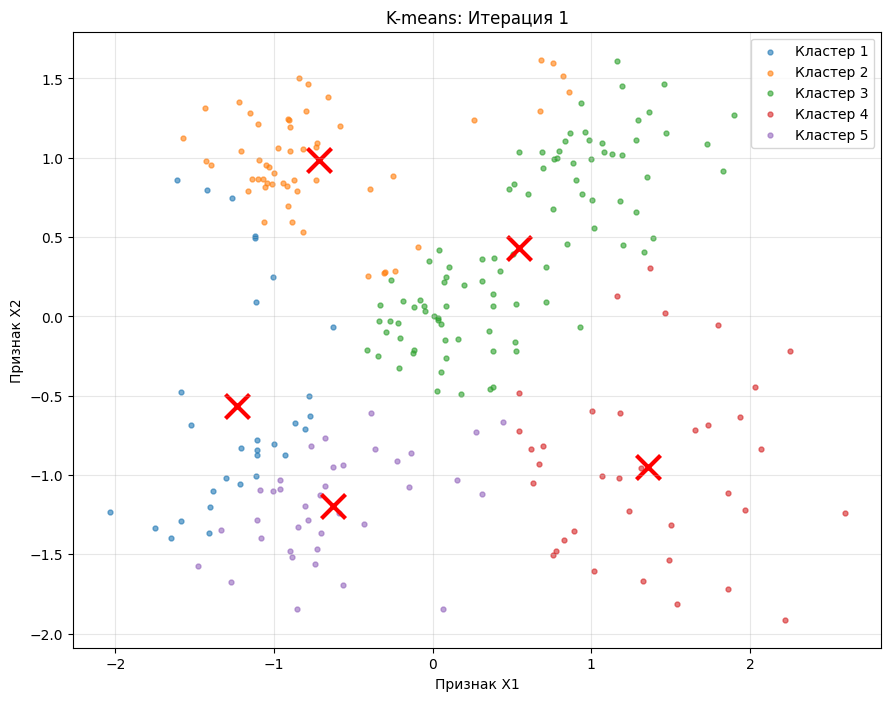

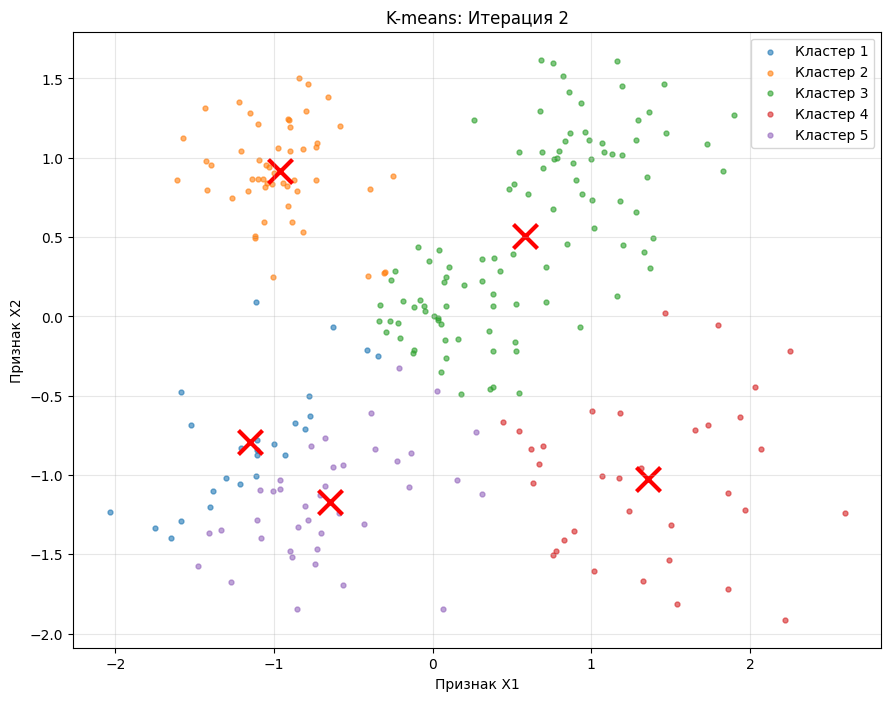

Итерация 2: 23 точек сменили кластер


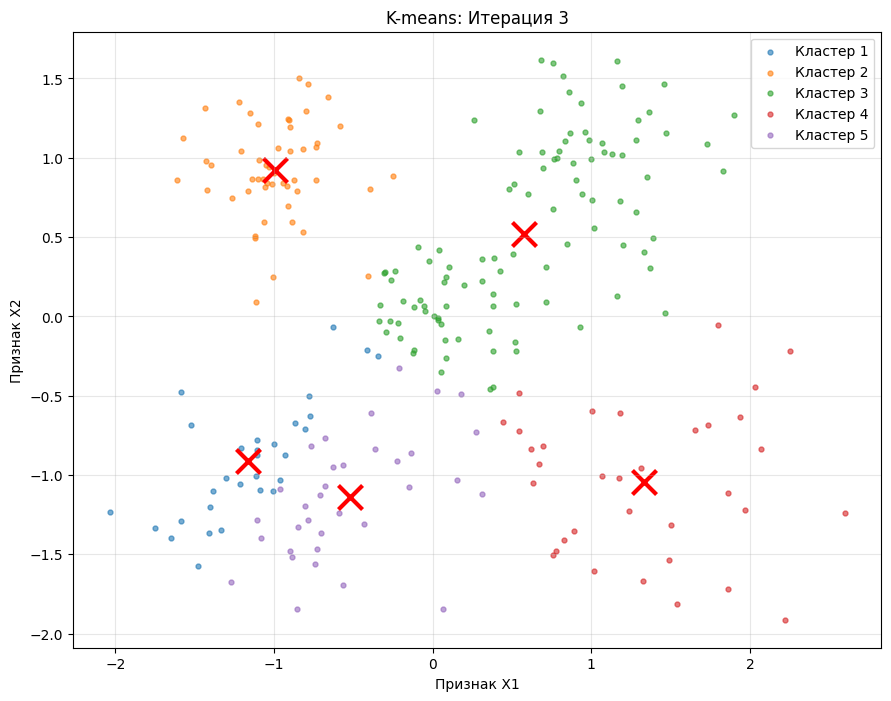

Итерация 3: 12 точек сменили кластер


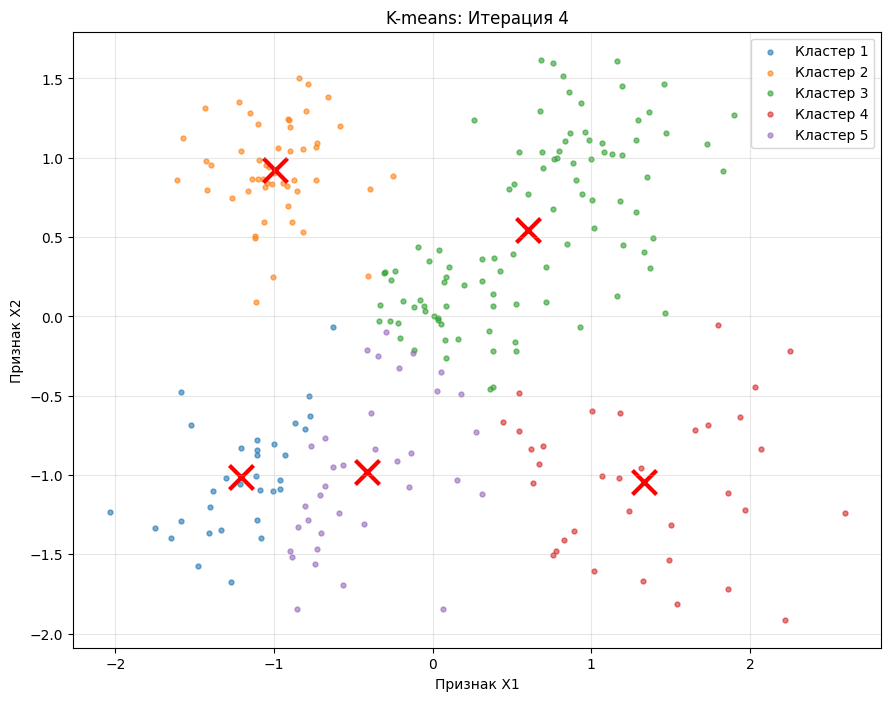

Итерация 4: 9 точек сменили кластер


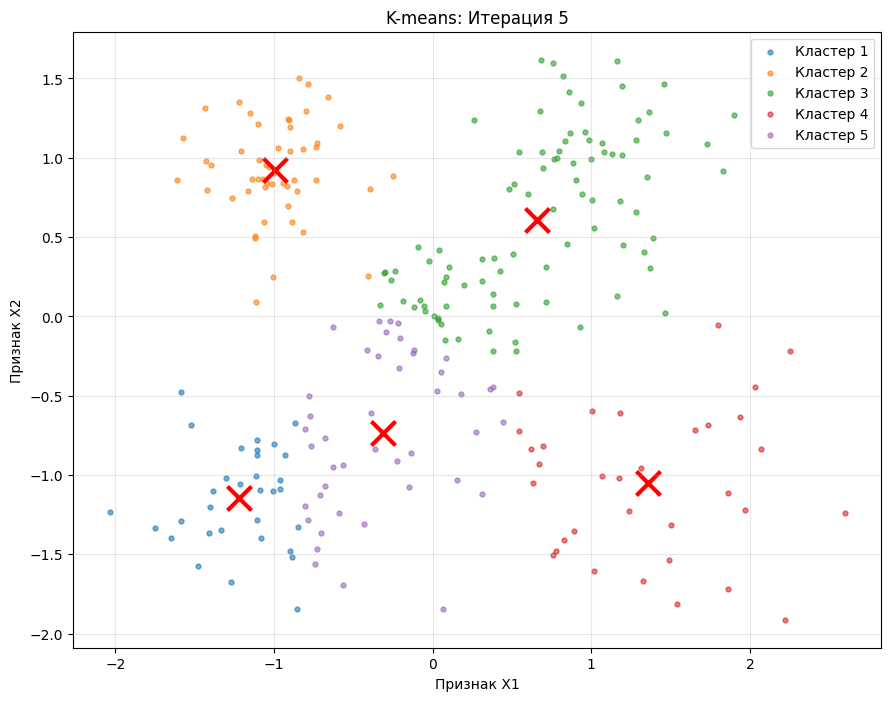

Итерация 5: 17 точек сменили кластер


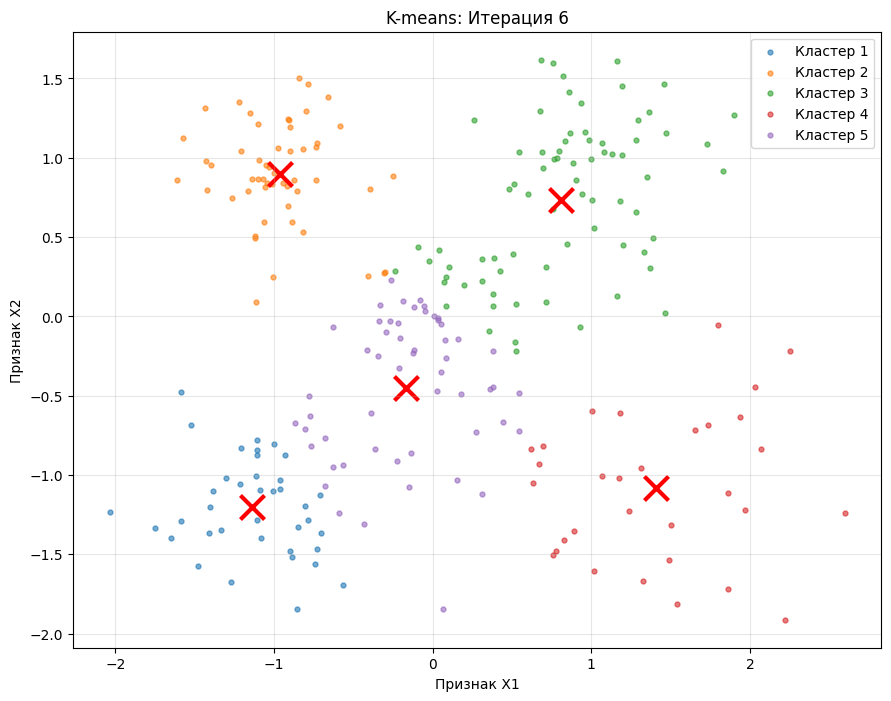

Итерация 6: 26 точек сменили кластер


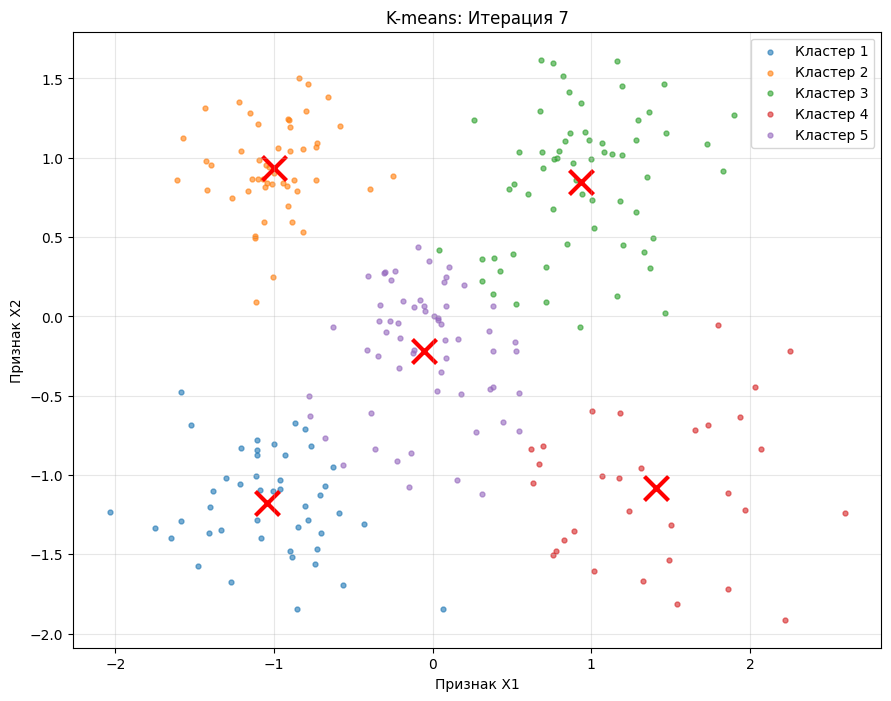

Итерация 7: 23 точек сменили кластер


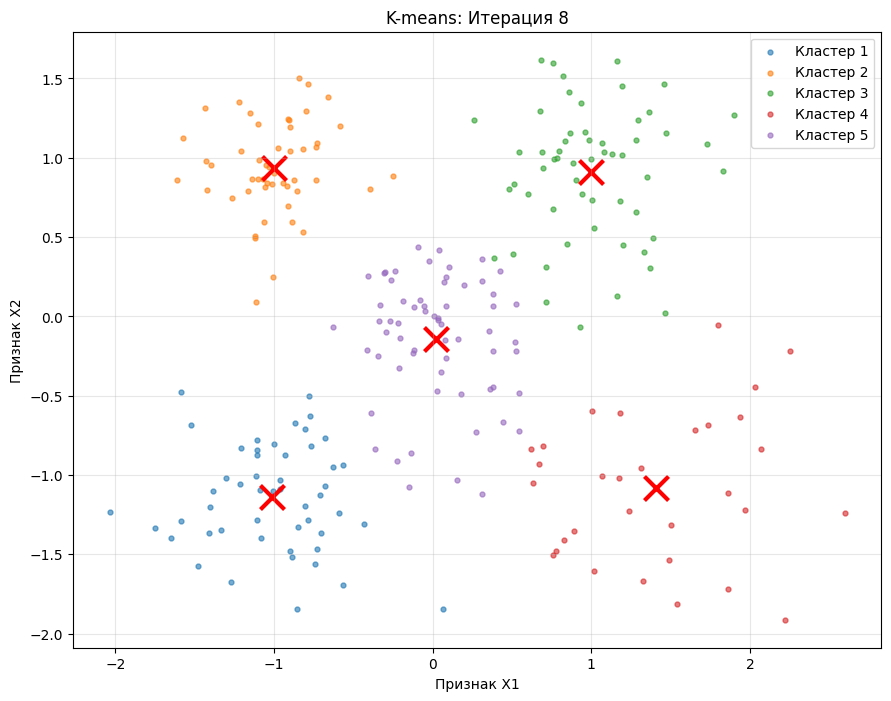

Итерация 8: 10 точек сменили кластер


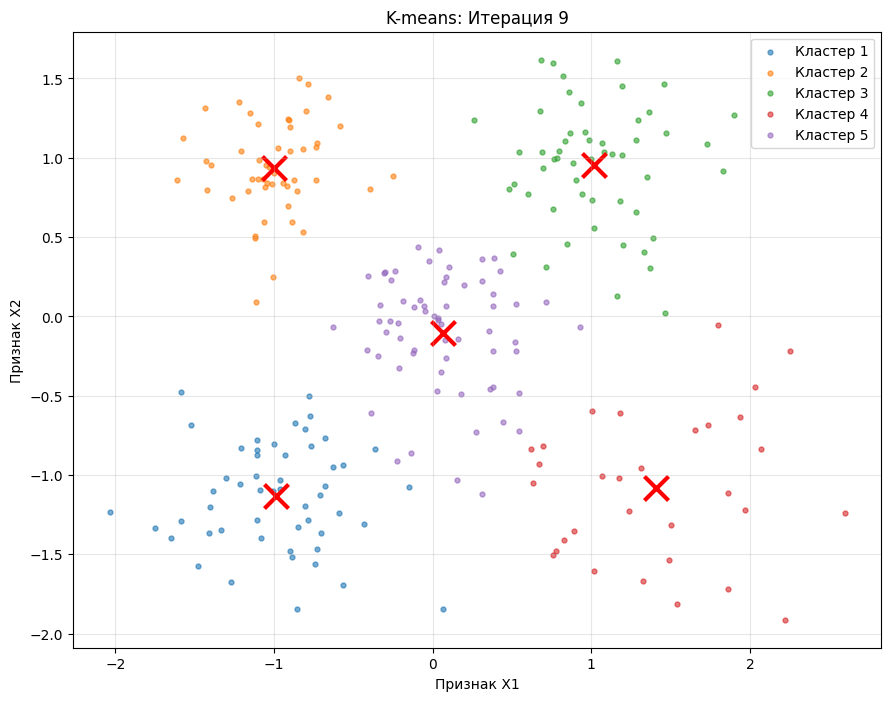

Итерация 9: 5 точек сменили кластер


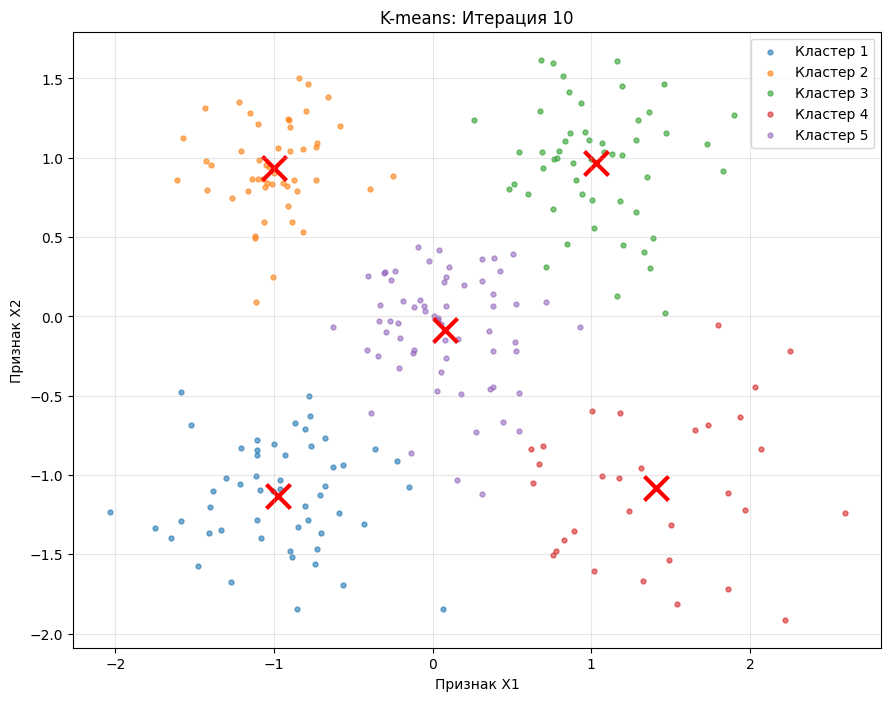

Итерация 10: 2 точек сменили кластер

Достигнуто максимальное количество итераций: 10


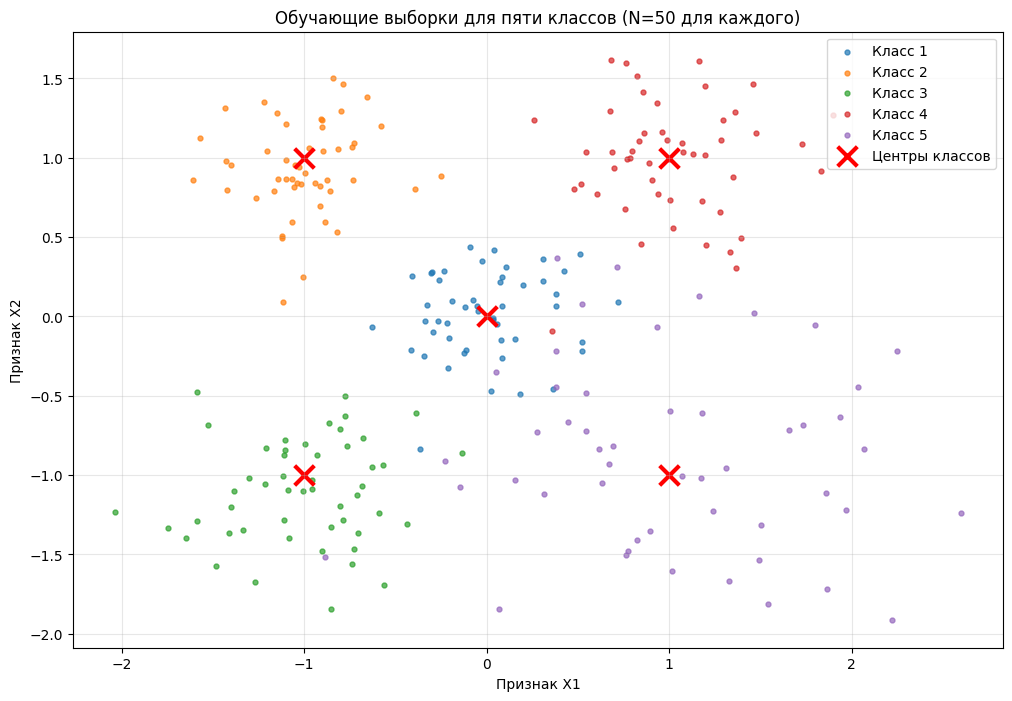

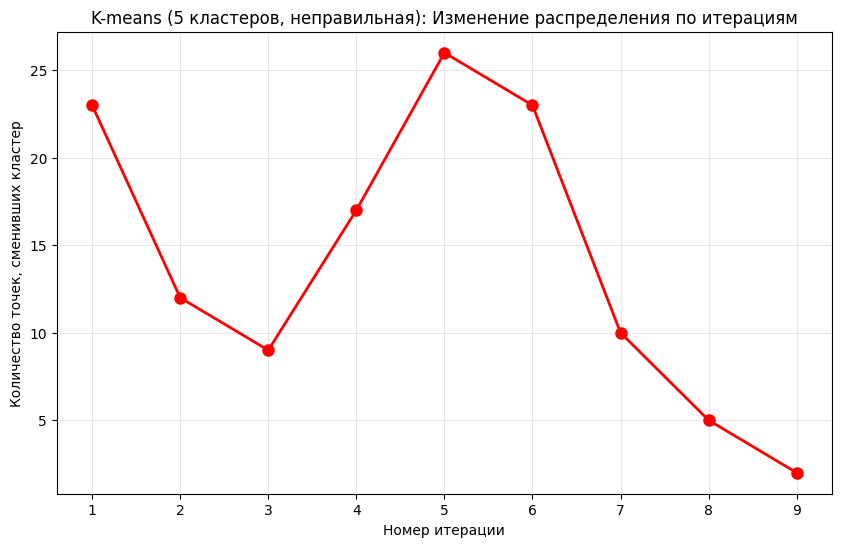

In [197]:
print("\n" + "="*70)
print("K-MEANS: 5 КЛАСТЕРОВ (НЕПРАВИЛЬНАЯ КЛАСТЕРИЗАЦИЯ)")
print("="*70)
printallM(all_M,"Правильные МО")
print("Начальные центры выбраны далеко от истинных центров классов")

# Начальные центры специально выбраны неудачно
initial_centers_bad = [
    np.array([-1.0, 0]),
    np.array([-0.5, 0.5]),
    np.array([0, 0]),
    np.array([1.0, -1.0]),
    np.array([0, -1])
]

centers_5_bad, count_changed_5_bad = k_mean_alg(
    big_sample, 5, initial_centers=initial_centers_bad, show_plots=True
)
show_right_version()
# График изменения количества точек, сменивших кластер
if len(count_changed_5_bad) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(count_changed_5_bad) + 1), count_changed_5_bad, 
             marker='o', linewidth=2, markersize=8, color='red')
    plt.xlabel('Номер итерации')
    plt.ylabel('Количество точек, сменивших кластер')
    plt.title('K-means (5 кластеров, неправильная): Изменение распределения по итерациям')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, len(count_changed_5_bad) + 1))
    plt.show()